## Colab Notebook created for ARAP module at UPC ETSETB.
Authors: Josep Vidal, Margarita Cabrera-Bean, Juan José Nieto

# MULTI-ARMED BANDIT
[Open to access Task Description](https://drive.google.com/file/d/1RVzAaeBRvH2kAVBug-I_aRHgMHbazkpB/view?usp=drive_link)


## 1 include libraries

In [201]:
import numpy as np
import seaborn as sns   
import matplotlib.pyplot as plt

## 2 fix random seed for result reproduction

In [202]:
np.random.seed(4)

## 3 Plot functions

We define two functions to support plot / draw of results

In [203]:
'''Insert title, and axis labels to plots'''
def insert_labels(labels, ax):
    if 'title' in labels:
        ax.set_title(labels['title'])
    if 'xlabel' in labels:
        ax.set_xlabel(labels['xlabel'])
    if 'ylabel' in labels:
	    ax.set_ylabel(labels['ylabel'])

def generate_plot(r, ba, reg, sr, q, strg, par, title, opt=None):
    str_legend = ['{}, {}={}'.format(['e-greedy', 'UCB', 'TS', 'UCB tracking'][strg], ['delta', 'c', 'K', 'alpha'][strg], p) for p in par]

    conf_1 = {'title': 'Average reward', 'xlabel': 'steps', 'ylabel': 'avg reward'}
    conf_2 = {'title': 'Percentage optimal actions', 'xlabel': 'steps', 'ylabel': '% optimal actions'}
    conf_3 = {'title': 'Average cumulative regret', 'xlabel': 'steps', 'ylabel': 'regret'}
    conf_4 = {'title': 'Reward on a single run', 'xlabel': 'steps', 'ylabel': 'reward'}
    conf_5 = {'title': str_legend[-1], 'xlabel': 'steps', 'ylabel': 'Q(a)'}

    fig, ax = plt.subplots(2,3, figsize=(18, 11))
    fig.suptitle(title)
    ax = ax.flatten()
    fig.delaxes(ax[5])
    for i, (data, conf) in enumerate(zip([r, ba, reg, sr, q],[conf_1, conf_2, conf_3, conf_4, conf_5])):
        for j, d in enumerate(data):
            ax[i].plot(d)
            insert_labels(conf, ax[i])
        if i < 4:
            ax[i].legend(str_legend)

    for i in [0, 3]:
        ax[i].plot(np.ones(len(d))*(np.max(meanA) if opt is None else opt)) # Include the optimum reward in the display

## 4 Multi-armed bandit setting

In [204]:
m = 10                                  # number of actions
dispMeansA = 1.5                        # dispersion in the values of means for every action
meanA = np.random.randn(m)*dispMeansA   # means for every action
bestAction = np.argmax(meanA)           # index of the best action
sigmas = [1, 0.1, 0.01]                 # std deviations of f(r|a) tested in a) and c)
sigmaUCB = 0.5                          # std deviation of f(r|a) used in b) and c)
alpha = 0.01                            # time constant for incremental estimation of Q in time-varying environment
print(meanA)
print(f"best action is {bestAction}")

[ 0.07584256  0.749927   -1.4938634   1.04039776 -0.62745228 -2.37686585
 -0.97156015  0.89786276  0.49837505 -1.72121495]
best action is 3


## 5 Simulation setting

In [205]:
NRuns = 100                             # number of independent runs to be averaged
NSteps = 501                            # number of time steps per run

r = np.zeros((NRuns, NSteps))           # instantaneous rewards
reg = np.zeros((NRuns, NSteps))         # instantaneous regret
Q = np.zeros((m, NSteps))               # average reward per action
BA = np.zeros((NRuns, NSteps))          # best action collection

Strats = [0, 1]                         # 0: e-greedy, 1: UCB

## 6 Decision taking setting

In [206]:
pars = [5 * np.array([0, 0.02, 0.2]),  # values of delta in e-greedy
        np.array([0.5, 1, 2])]          # values of c in UCB

## 7 Random trials for each parameter of the algorithm and for all independent runs

In [207]:
results = []
stds = [[np.ones(m)*s for s in sigmas + [sigmaUCB]],                    # e-greedy: variances of a) and c)
        [np.ones(m)*s for s in [sigmaUCB] + sigmas]]                    # UCB: variances of b) and c)
for Strat in Strats:                                                    # decision strategies
    par = pars[Strat]
    results.append([])
    for std in stds[Strat]:                                             # variances of f(r|a)
        avg_r = []
        avg_ba = []
        avg_reg = []
        single_r = []
        for e in range(len(par)):                                       # parameters for the method
            BA = np.zeros((NRuns, NSteps))                              # identifies if best action has been selected
            for i in range(NRuns):
                Q = np.zeros((m, NSteps))                               # average reward per action
                Q[:,0] = np.random.randn(m)*0.1                         # initialization of Q
                ta = np.zeros((m))                                      # times each action is selected
                for j in range(1, NSteps):
                    # e-greedy
                    if not Strat:
                        I = np.argmax(Q[:,j-1])                         # select best action
                        if np.random.rand() > min(1, m*par[e]/j):       # e-greedy with decaying epsilon
                            a = I
                        else:
                            a = np.random.randint(m)
                    # UCB
                    else:
                        U = np.sqrt(par[e]*std**2*np.log(j)/(ta+1e-4))  # upper confidence bound for gaussian rewards
                        a = np.argmax(Q[:,j-1] + U)
                    ta[a] += 1
                    r[i,j] = meanA[a] + np.random.randn()*std[a]        # obtain the gaussian reward
                    Q[:,j] = Q[:, j-1]                                  # update Q function
                    Q[a,j] += 1/ta[a] * (r[i,j] - Q[a, j])

                    BA[i,j] += bestAction == a
                    reg[i,j] = np.max(meanA) - meanA[a]                 # regret w.r.t. the best action

            avg_r.append(np.mean(r.copy(), axis=0))
            avg_ba.append(np.mean(BA.copy(), axis=0)*100)
            avg_reg.append(np.mean(np.cumsum(reg, axis=1), axis=0))     # cumulative regret over time
            single_r.append(r[-1].copy())                               # reward on a single run
        results[Strat].append((avg_r, avg_ba, avg_reg, single_r, Q.copy()))

## 8 Plot results

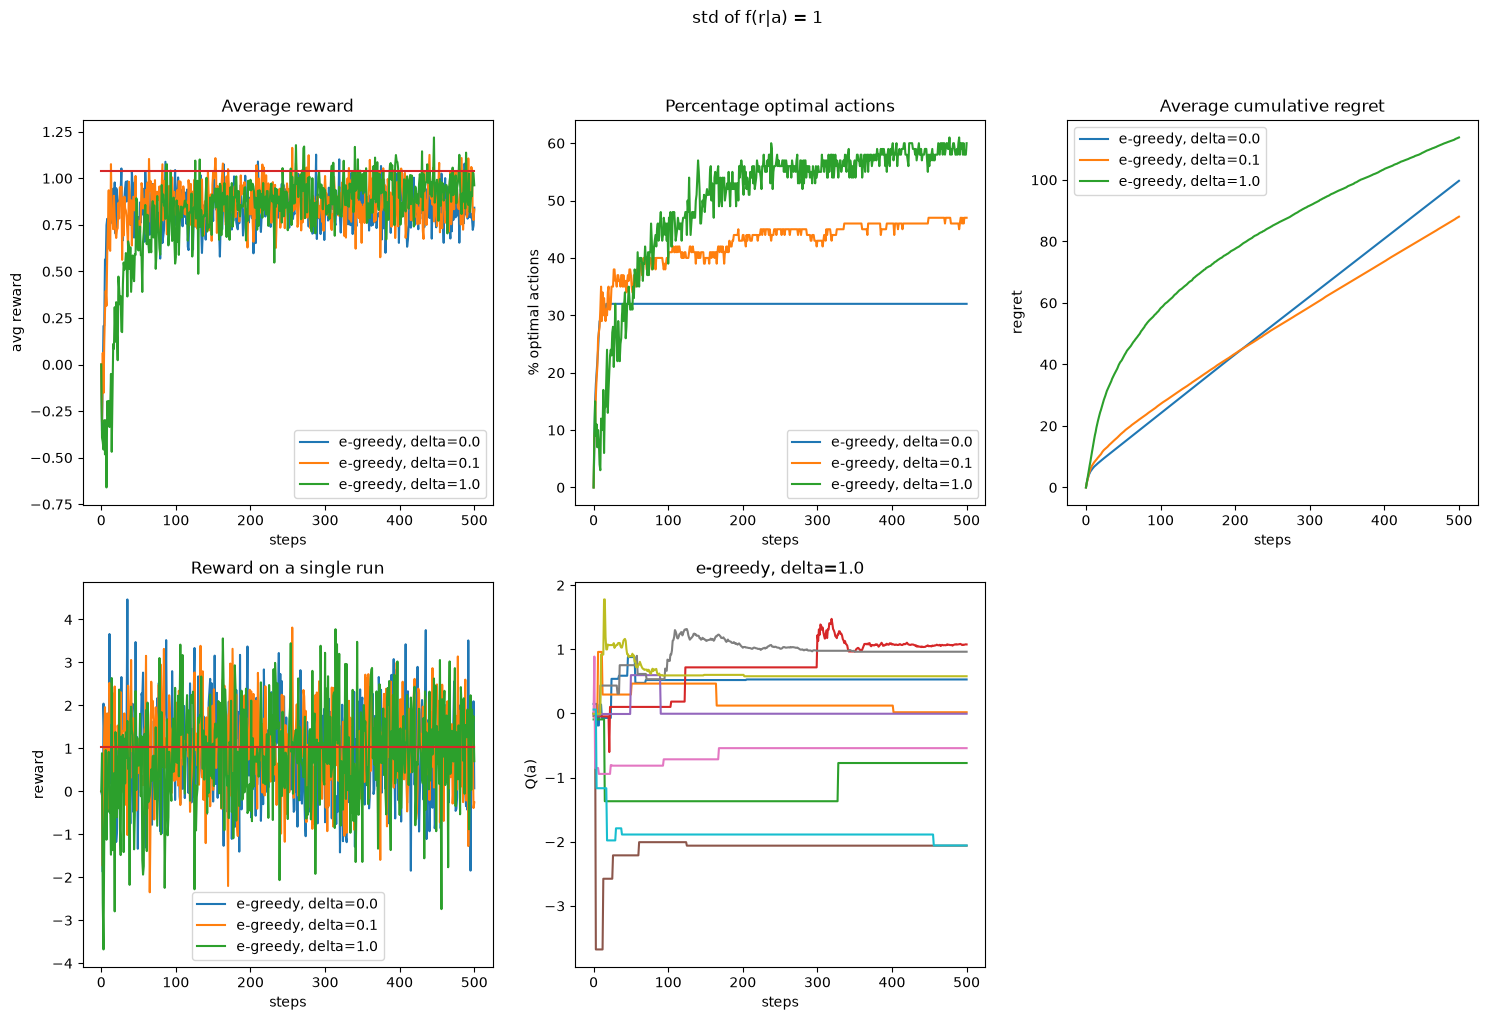

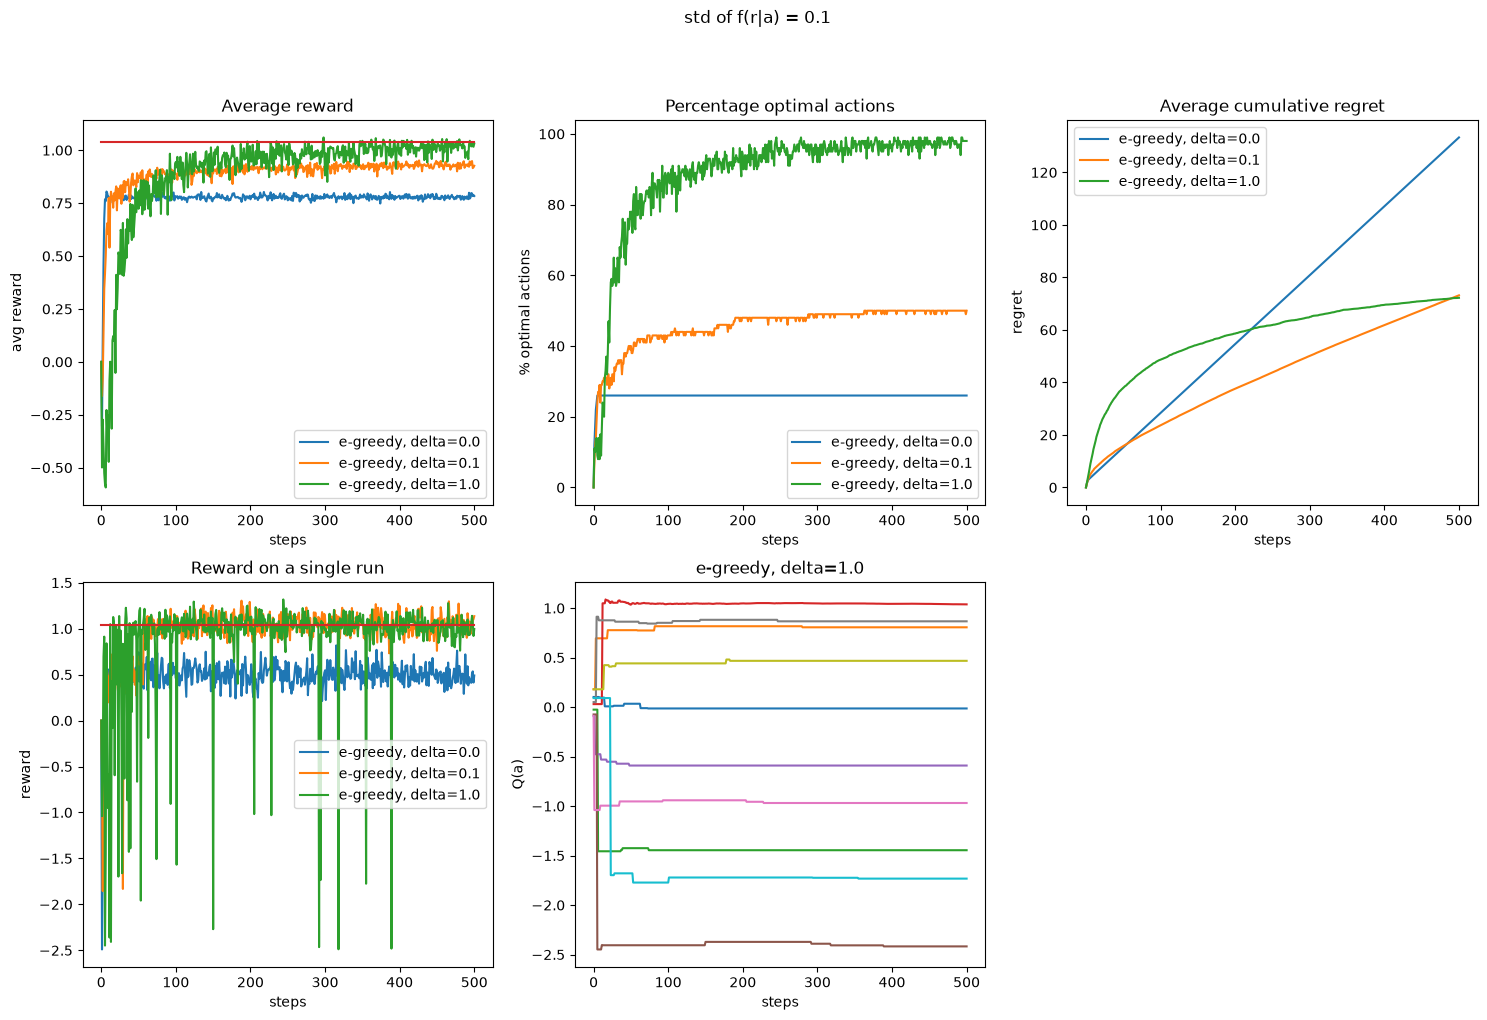

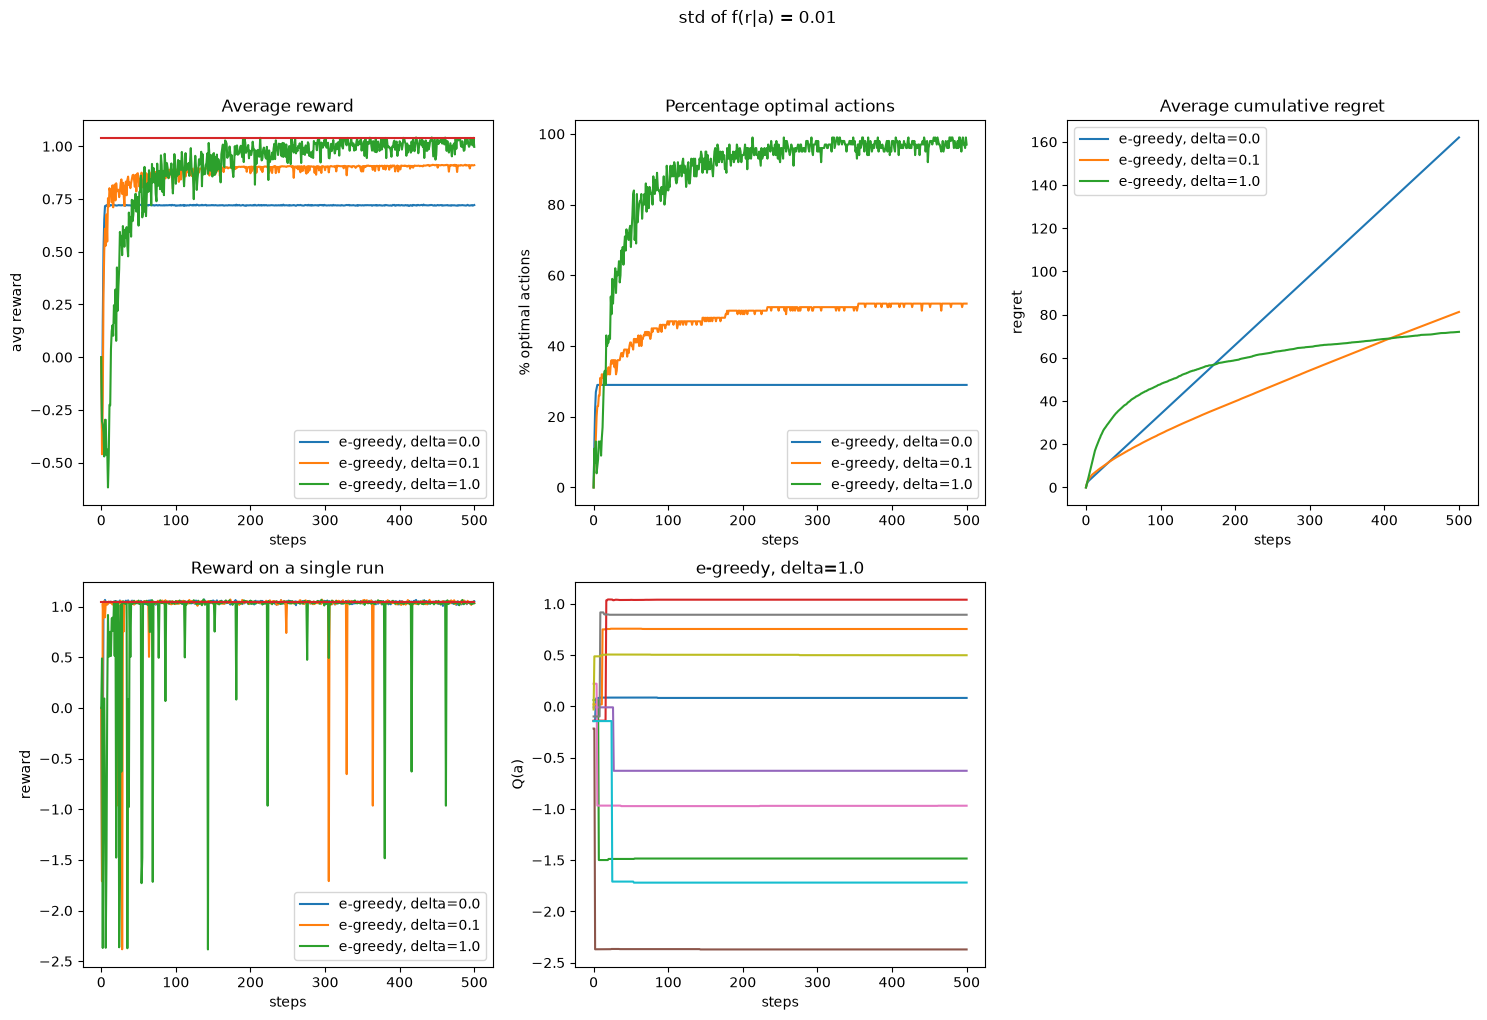

In [208]:
for sigma, (avg_r, avg_ba, avg_reg, single_r, Q) in zip(sigmas, results[0]):       # e-greedy
    generate_plot(avg_r, avg_ba, avg_reg, single_r, Q, 0, pars[0], 'std of f(r|a) = {}'.format(sigma))

## Report

### a)

With $\sigma=1$ the reward on a single run is very noisy and so are the Q(a) estimates. Even with $\delta=1$ the best action is only chosen about $60\%$ of the time and the regret keeps growing for every delta. The chosen action plot shows high variability due to that specifically.

With smaller variances $(0.1, 0.01)$ the single run reward stays almost constant at the value of the chosen arm and only drops when exploring. Q(a) gets close to the true means after a few samples.

With enough exploration ($\delta=1$) this gives almost $100\%$ optimal actions and the regret flattens, growing roughly like a logarithm. It is higher at the start because of exploration, but ends up the lowest.

With little or no exploration ($\delta=0.1, \delta=0$) the agent locks on a suboptimal arm early and the regret grows linearly even with very low noise.

The conclusion is low variance makes learning easier but the regret still depends on exploring enough.

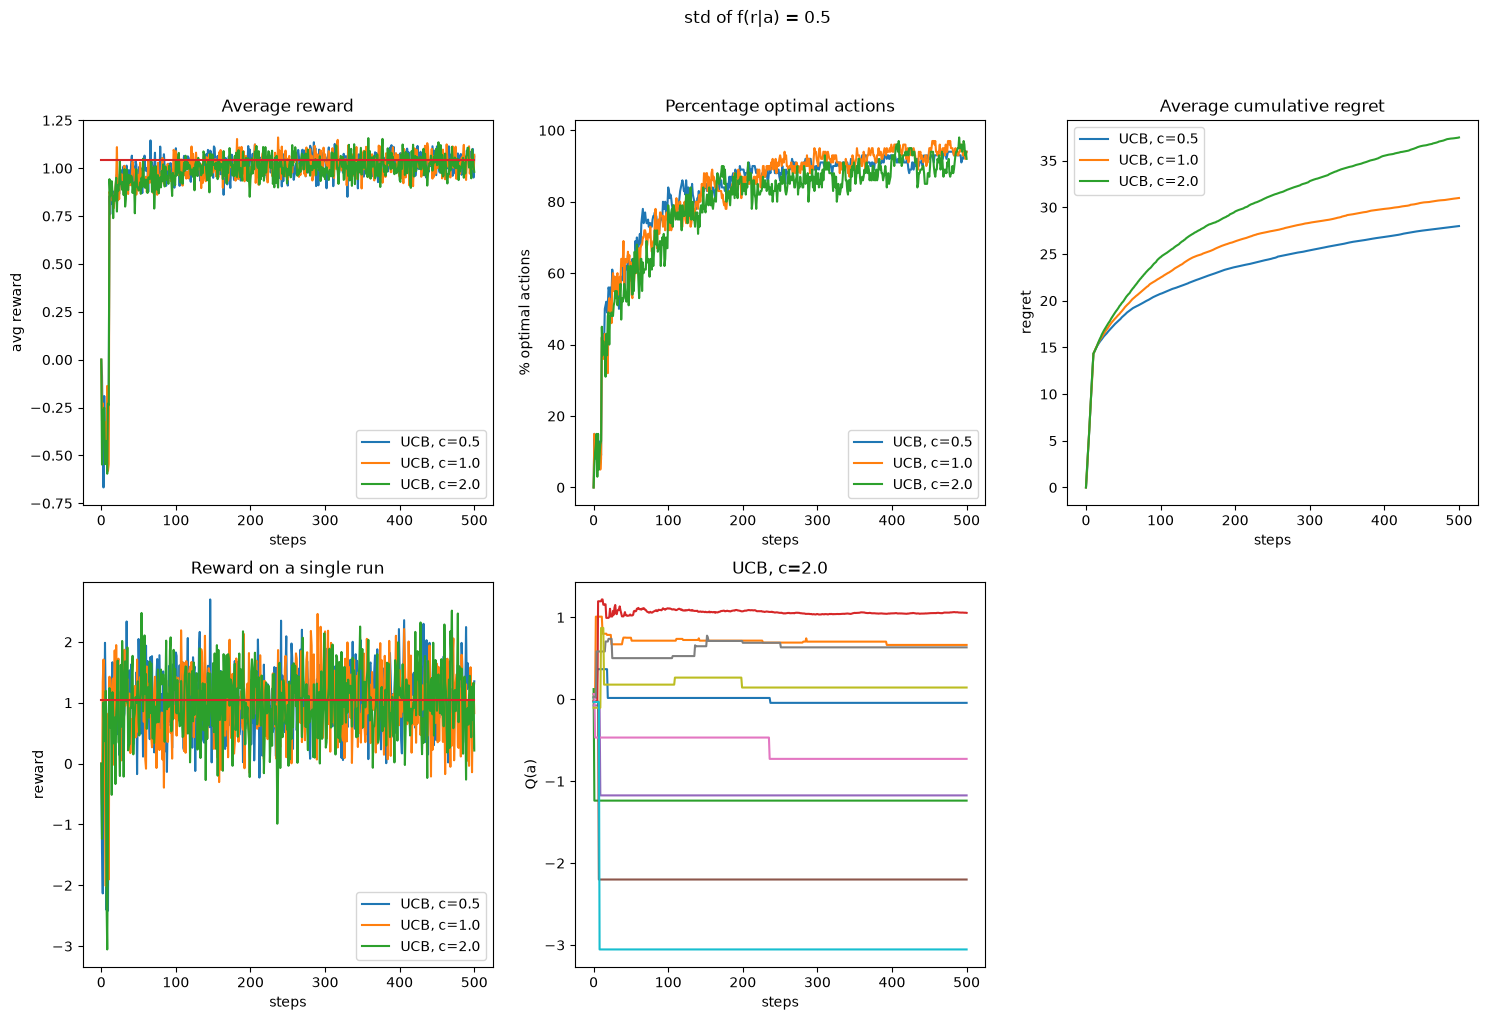

In [209]:
avg_r, avg_ba, avg_reg, single_r, Q = results[1][0]
generate_plot(avg_r, avg_ba, avg_reg, single_r, Q, 1, pars[1], 'std of f(r|a) = {}'.format(sigmaUCB))

In [210]:
for k, c in enumerate(pars[1]):
    print('c =', c)
    print('avg reward in convergence:', np.mean(avg_r[k][-100:]).round(2))
    print('% optimal actions at steps 100, 250, 500:', avg_ba[k][[100, 250, 500]])
    print('regret at steps 100, 250, 500:', avg_reg[k][[100, 250, 500]].round(1))
print('Q(a) on a single run:', Q[:,-1].round(2))
print('true q*(a):', meanA.round(2))

c = 0.5
avg reward in convergence: 1.03
% optimal actions at steps 100, 250, 500: [84. 86. 94.]
regret at steps 100, 250, 500: [20.7 24.5 28. ]
c = 1.0
avg reward in convergence: 1.03
% optimal actions at steps 100, 250, 500: [77. 93. 94.]
regret at steps 100, 250, 500: [22.5 27.5 31. ]
c = 2.0
avg reward in convergence: 1.02
% optimal actions at steps 100, 250, 500: [79. 83. 92.]
regret at steps 100, 250, 500: [24.7 31.3 37.5]
Q(a) on a single run: [-0.04  0.66 -1.24  1.05 -1.17 -2.2  -0.73  0.63  0.14 -3.05]
true q*(a): [ 0.08  0.75 -1.49  1.04 -0.63 -2.38 -0.97  0.9   0.5  -1.72]


### b)

UCB for Gaussian rewards selects $a_t = \arg\max_a \left[ Q_t(a) + \sqrt{c\,\sigma_a^2 \ln t / N_t(a)} \right]$, it's now tested with $\sigma=0.5$.

The average reward in convergence is $1.03$ for $c=0.5$ and $c=1$ while $1.02$ for $c=2$, very close to the optimum $1.04$. The percentage of correct decisions grows fast and ends at $92$-$94\%$ for every c. A larger c gives more weight to the uncertainty term, so it explores more and converges slower: at step $250$, $c=2$ chooses the best action $83\%$ of the time vs $86\%$ and $93\%$ for $c=0.5$ and $c=1$. It also ends with the highest regret ($37.5$ vs $28.0$ for $c=0.5$).

On a single run only the best arms have an accurate $Q(a)$, which is hard to discard and keeps being exploited. Arms that are clearly bad are tried once or twice and then abandoned, so their $Q(a)$ stays wrong. Once an arm's upper bound falls below the best estimate it is no longer selected.

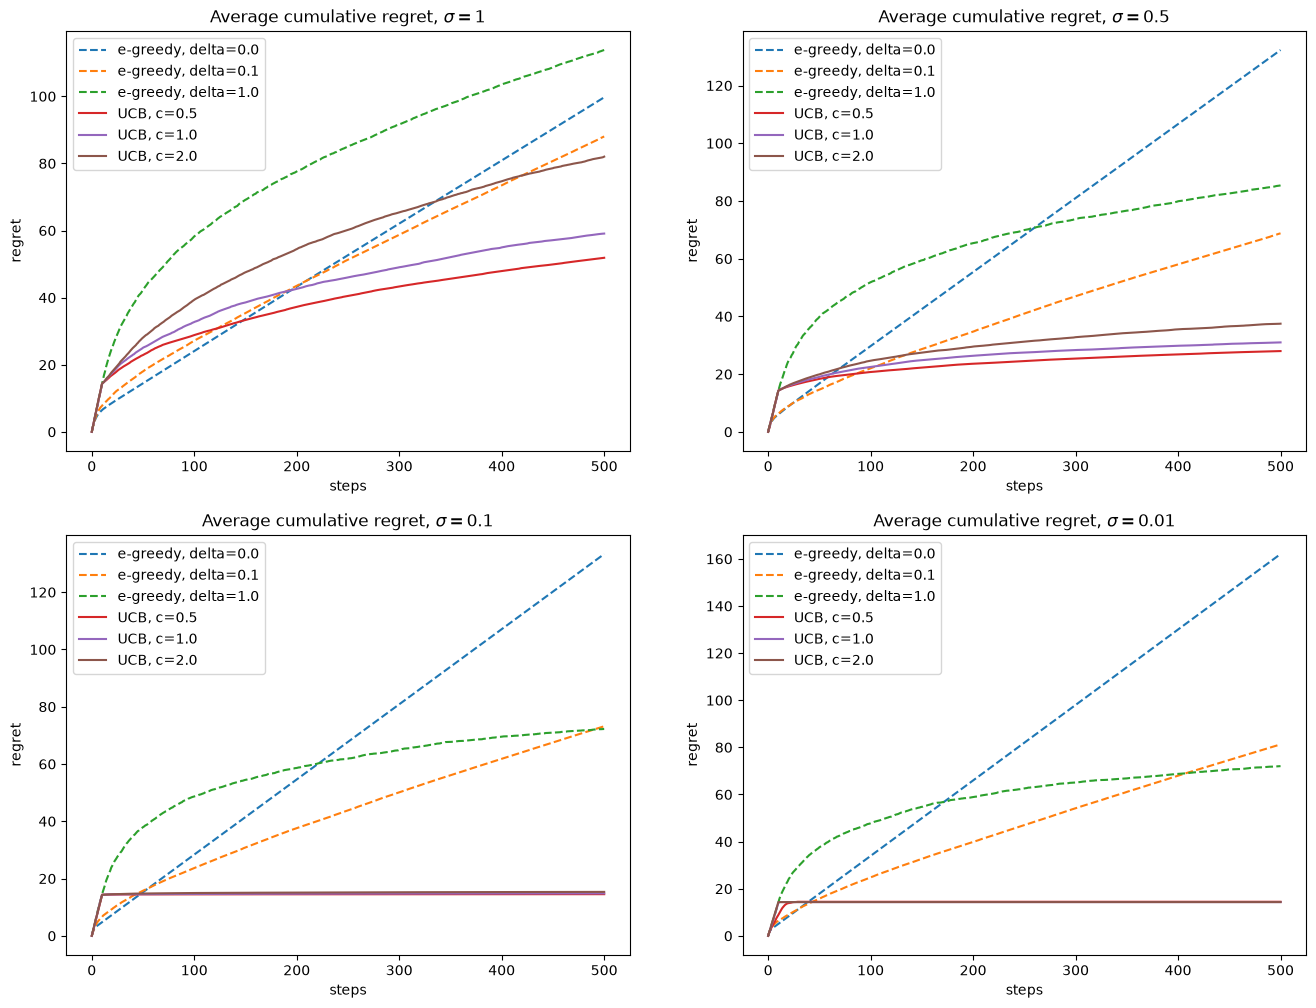

In [211]:
sig_eg = sigmas + [sigmaUCB]
sig_ucb = [sigmaUCB] + sigmas

fig, ax = plt.subplots(2, 2, figsize=(16, 12))
ax = ax.flatten()
for i, s in enumerate([1, 0.5, 0.1, 0.01]):
    reg_eg = results[0][sig_eg.index(s)][2]
    reg_ucb = results[1][sig_ucb.index(s)][2]
    for k, d in enumerate(pars[0]):
        ax[i].plot(reg_eg[k], '--', label='e-greedy, delta={}'.format(d))
    for k, c in enumerate(pars[1]):
        ax[i].plot(reg_ucb[k], label='UCB, c={}'.format(c))
    insert_labels({'title': r'Average cumulative regret, $\sigma={}$'.format(s), 'xlabel': 'steps', 'ylabel': 'regret'}, ax[i])
    ax[i].legend()
plt.show()

### c)

Both algorithms are compared for $\sigma = 1, 0.5, 0.1, 0.01$.

UCB pays a cost at the start, when it tries every arm and then its regret flattens and grows logarithmically ($\ln t$). Its exploration depends on the variance, since the uncertainty term is proportional to $\sigma$. With high variance it keeps exploring for longer and the regret keeps growing. With low variance, one sample per arm is enough, so the regret becomes constant after the first steps and $c$ makes no difference.

The e-greedy exploration does not depend on the variance, it follows the same random schedule in all cases. With little or no exploration ($\delta=0$, $\delta=0.1$) the agent often locks on a suboptimal arm and the regret grows linearly for every variance. With $\delta=1$ the regret flattens, but it pays a large exploration cost even when the noise is so low that it is not needed.

UCB ends with the lowest regret in every case. The gap is largest with low variance, where UCB adapts its exploration to the noise and stops exploring almost immediately. With high variance the gap is smaller, because UCB also has to explore more to tell the arms apart.

## Practical Application

### d)

From the example paper I chose the problem on section 2.9 [Kerkouche et al., 2018]: a LoRa node thats sends one packet per time slot to a gateway and has to choose how to transmit it. Robust settings lose fewer packets but use more battery, so the node has to learn the best trade-off. All the configuration values are obtained from the original paper tables.

**Arms**

 Each action $a \in \mathcal{A}$ is a pair (spreading factor SF, transmission power P), with $m = |\mathcal{A}| = 9$ arms: SF7 with $P = 2, 6, 10, 14$ dBm and SF8 to SF12 with $P = 14$ dBm. A higher SF makes the packet last longer in the air, from $ToA = 0.04$ s for SF7 to $0.99$ s for SF12 (section VI-A). In other words, it is more robust but spends more energy.

**Reward**

A transmission either arrives or is lost. The paper defines a cost and a reward in $[0,1]$:

$$Cost(a) = \mathcal{E}(a) + penalty \cdot \mathbb{1}\{\text{lost}\}, \qquad r = 1 - \frac{Cost(a)}{C_{max}}$$

where $\mathcal{E}(a) = ToA(a) \cdot P(a)$ is the energy of the transmission (time on air $\times$ power, with $P$ in W $= 10^{P_{dBm}/10}/1000$) and $C_{max} = \max_a \mathcal{E}(a) + penalty$ is the largest possible cost.

**Probability of success**

The packet arrives if the received power is above the sensitivity $S(a)$ of the gateway, from $-124$ dBm for SF7 to $-137$ dBm for SF12 (Table I). The received power is $P + G - PL$ with the so called Rayleigh fading,  which gives:

$$p(a) = \exp\left(-10^{(S(a) - P(a) - G + PL)/10}\right)$$

with the parameters of the antenna gain $G = -5$ dBi and path loss $PL = 126$ dB (Okumura-Hata model used in the paper, for a node at 1000 m).

**Action value**

The reward distribution $f(r|a)$ only takes two values: $r = 1 - \mathcal{E}(a)/C_{max}$ with probability $p(a)$ and $r = 1 - (\mathcal{E}(a) + penalty)/C_{max}$ with probability $1 - p(a)$. The action value is its mean:

$$Q(a) = E\{r \mid A = a\} = 1 - \frac{\mathcal{E}(a) + penalty \cdot (1 - p(a))}{C_{max}}, \qquad V^* = Q(a^*) = \max_a Q(a)$$

The best arm $a^*$ is SF8 with 14 dBm: lower settings lose too many packets and higher ones spend too much energy.

**Simplifications**

- One transmission per time slot instead of 8. With retransmissions almost no packet is lost and all arms gave nearly the same reward.
- $penalty = 0.02$ J instead of 1. The paper says it depends on the application. This value is about the energy of one SF12 transmission, so energy and losses have a similar weight.
- A single node with a fixed path loss: no collisions with other nodes.
- 5000 time slots instead of 1000, so that the algorithms have time to converge and their differences are clear.

Since $f(r|a)$ is not Gaussian, UCB uses the bound of the slides for finite-domain rewards:

$$a_t = \arg\max_a \left[ \hat{Q}_t(a) + \sqrt{\frac{c\,(r^M_a - r^m_a)^2 \ln t}{2 N_t(a)}} \right], \qquad r^M_a - r^m_a = \frac{penalty}{C_{max}}$$

In [212]:
# Arms config
SF = np.array([7, 7, 7, 7, 8, 9, 10, 11, 12])                  
P = np.array([2, 6, 10, 14, 14, 14, 14, 14, 14])               
mL = len(SF)                                                   
S = np.array([-124, -127, -130, -133, -135, -137])[SF - 7]
ToA = np.array([0.04, 0.07, 0.14, 0.25, 0.49, 0.99])[SF - 7]

# Constants
G = -5
PL = 126
penalty = 0.02
E = ToA * 10**(P/10) / 1000
Cmax = np.max(E) + penalty

# Probability of success, action values and best action
def lora_values(PL):
    pA = np.exp(-10**((S - P - G + PL)/10))
    qA = 1 - (E + penalty*(1 - pA))/Cmax
    return pA, qA

pA, qA = lora_values(PL)
bestL = np.argmax(qA)
NStepsL = 5001

# packet lost with probability 1 - p(a)
def bandit_lora(a, pA):
    lost = np.random.rand() > pA[a]                               
    return 1 - (E[a] + penalty*lost)/Cmax

print('p(a): ', pA.round(2))
print('Q(a): ', qA.round(3))
print(f"best action is arm {bestL+1}: SF{SF[bestL]}, P={P[bestL]} dBm")

p(a):  [0.04 0.28 0.61 0.82 0.9  0.95 0.98 0.98 0.99]
Q(a):  [0.572 0.677 0.815 0.897 0.918 0.9   0.849 0.719 0.441]
best action is arm 5: SF8, P=14 dBm


In [ ]:
# K values for Thompson sampling (section e) and step sizes alpha for UCB tracking (section g)
parsL = pars + [np.array([1, 5, 20]), np.array([0.01, 0.02, 0.05])]

def run_lora(pA_t, qA_t, strats=[0, 1, 2]):
    resultsL = []
    # 0: e-greedy, 1: UCB, 2: Thompson sampling (section e), 3: UCB tracking (section g)
    for Strat in strats:   
        par = parsL[Strat]
        avg_r = []
        avg_ba = []
        avg_reg = []
        single_r = []

        for e in range(len(par)):                                           
            r = np.zeros((NRuns, NStepsL))              
            reg = np.zeros((NRuns, NStepsL))            
            BA = np.zeros((NRuns, NStepsL))             

            for i in range(NRuns):
                Q = np.zeros((mL, NStepsL))
                Q[:,0] = np.random.randn(mL)*0.1
                ta = np.zeros((mL))
                alpha_a = np.ones(mL)                       
                beta_a = np.ones(mL)                        
                for j in range(1, NStepsL):

                    # e-greedy
                    if not Strat:
                        I = np.argmax(Q[:,j-1])                       
                        if np.random.rand() > min(1, mL*par[e]/j):    
                            a = I
                        else:
                            a = np.random.randint(mL)
                    # UCB 
                    elif Strat in [1, 3]:
                        c = par[e] if Strat == 1 else 0.5
                        U = np.sqrt(c*(penalty/Cmax)**2*np.log(j)/(2*(ta+1e-4))) 
                        a = np.argmax(Q[:,j-1] + U)
                    # Thompson sampling 
                    else:
                        theta = np.random.beta(alpha_a, beta_a, (par[e], mL))      
                        Qk = 1 - (E + penalty*(1 - theta))/Cmax                    
                        a = np.argmax(np.mean(Qk, axis=0))                         
                    ta[a] += 1
                    r[i,j] = bandit_lora(a, pA_t[j])                         
                    Q[:,j] = Q[:, j-1]                              
                    step = 1/ta[a] if Strat != 3 else max(1/ta[a], par[e])     
                    Q[a,j] += step * (r[i,j] - Q[a, j])

                    if Strat == 2:                                          
                        lost = round(((1 - r[i,j])*Cmax - E[a])/penalty)
                        alpha_a[a] += 1 - lost
                        beta_a[a] += lost

                    BA[i,j] += np.argmax(qA_t[j]) == a
                    reg[i,j] = np.max(qA_t[j]) - qA_t[j][a]                      

            avg_r.append(np.mean(r, axis=0))
            avg_ba.append(np.mean(BA, axis=0)*100)
            avg_reg.append(np.mean(np.cumsum(reg, axis=1), axis=0))      
            single_r.append(r[-1].copy())                                
        resultsL.append((avg_r, avg_ba, avg_reg, single_r, Q.copy()))
    return resultsL

resultsL = run_lora(np.tile(pA, (NStepsL, 1)), np.tile(qA, (NStepsL, 1)))

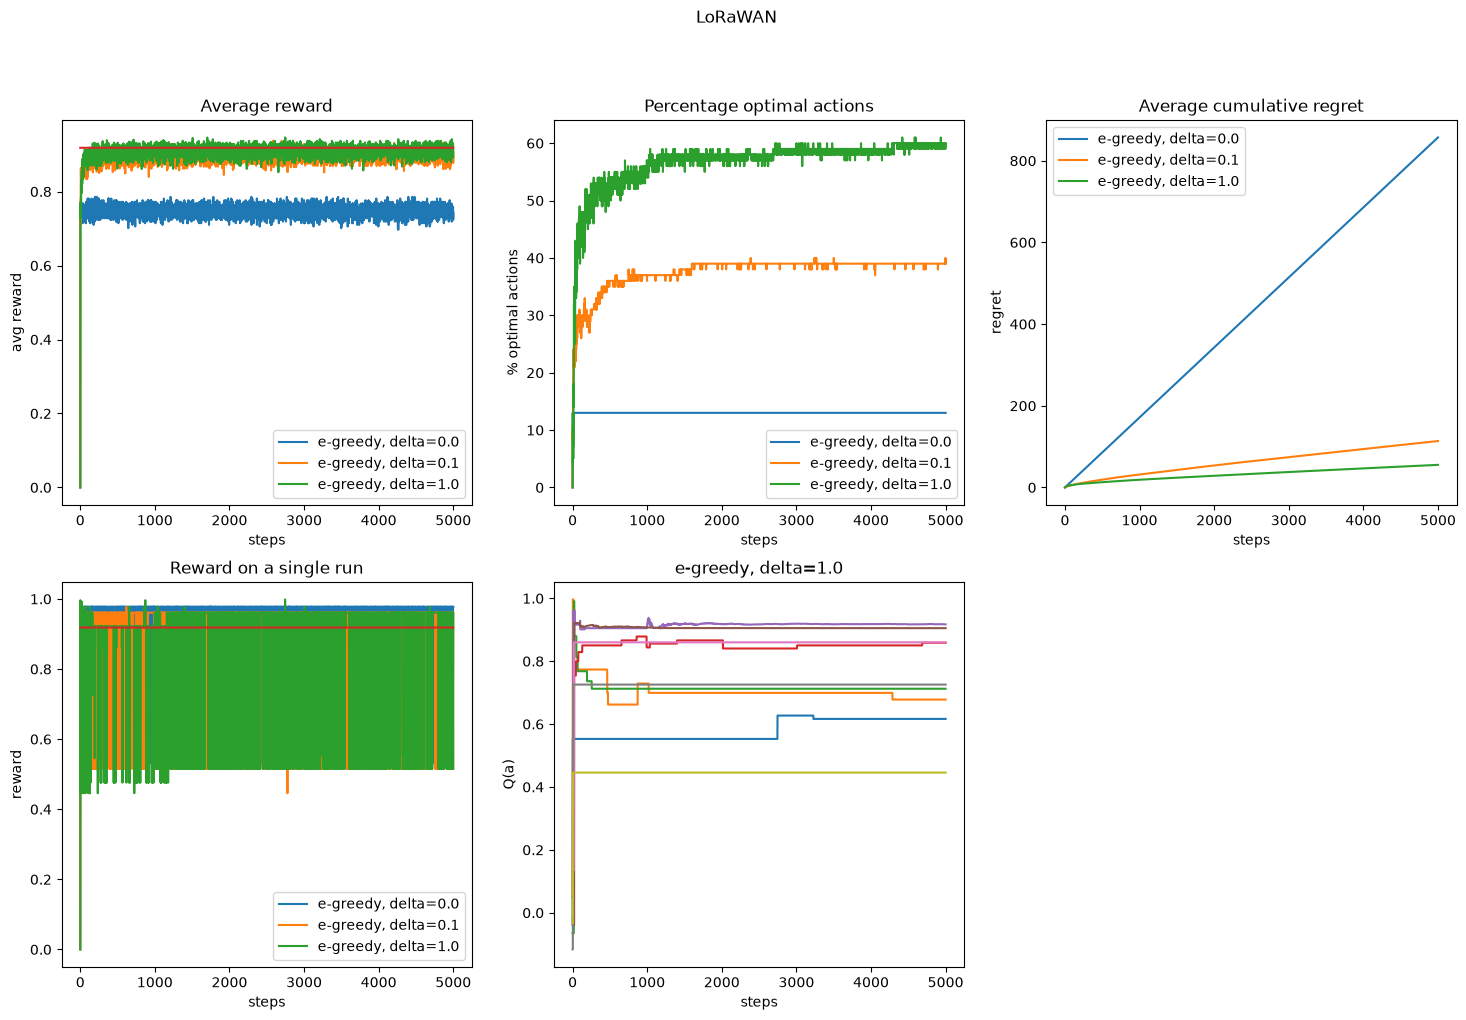

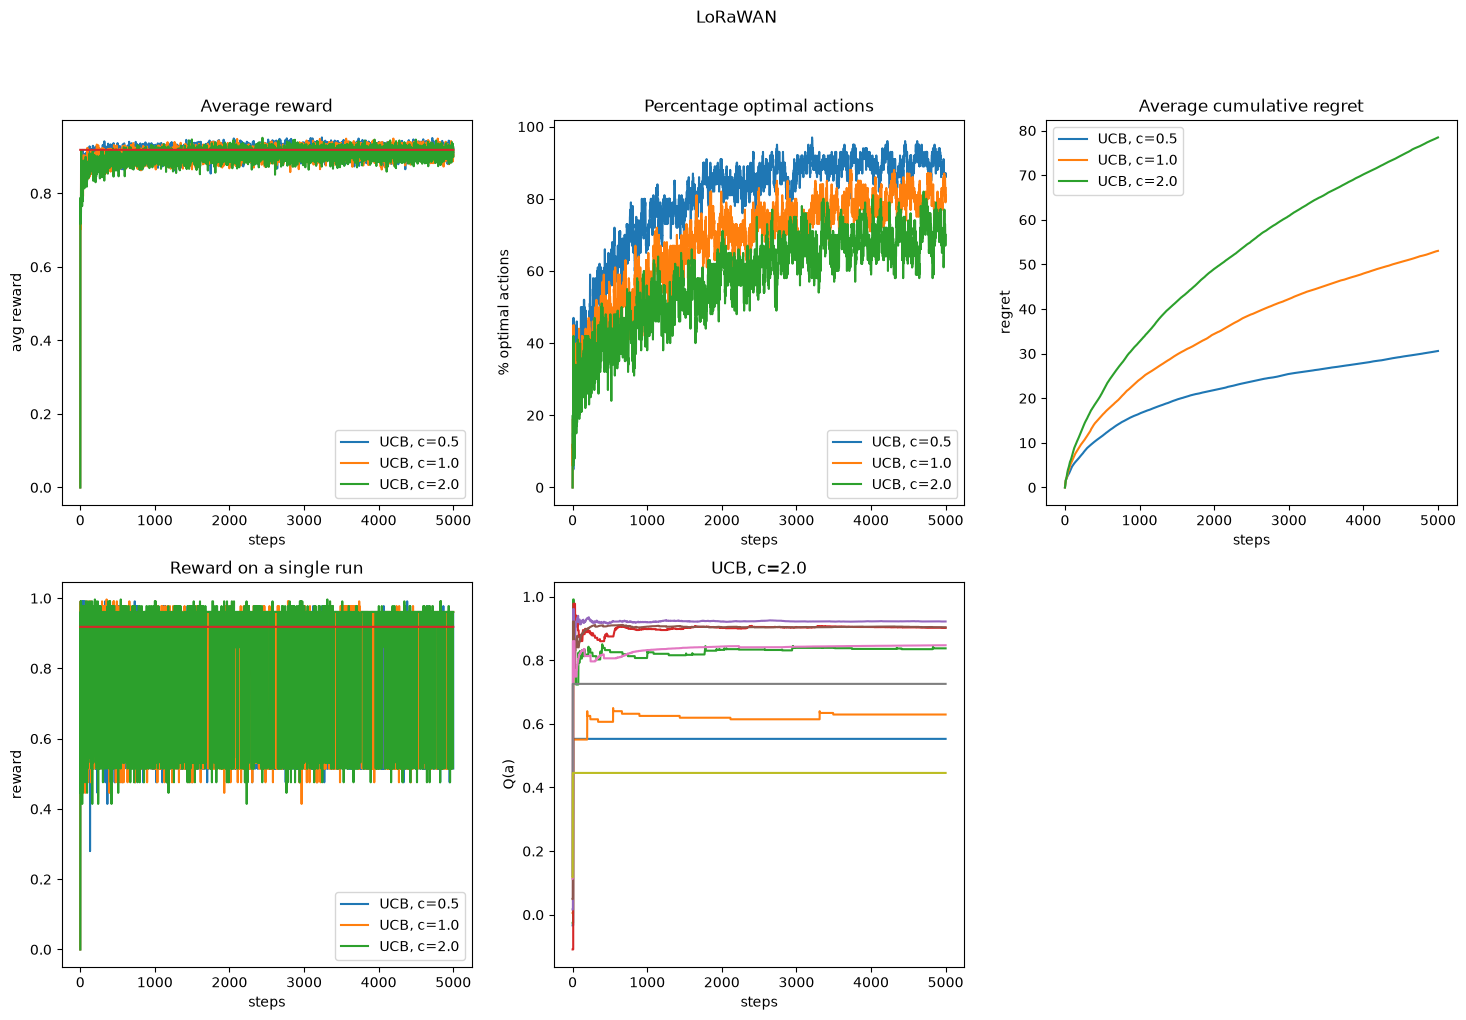

In [ ]:
for Strat in [0, 1]:
    avg_r, avg_ba, avg_reg, single_r, Q = resultsL[Strat]
    generate_plot(avg_r, avg_ba, avg_reg, single_r, Q, Strat, parsL[Strat], 'LoRaWAN', qA[bestL])

In [ ]:
for Strat in [0, 1]:
    avg_r, avg_ba, avg_reg, single_r, Q = resultsL[Strat]
    for k, p in enumerate(parsL[Strat]):
        print('UCB, c =' if Strat else 'e-greedy, delta =', p)
        print('avg reward in convergence:', np.mean(avg_r[k][-100:]).round(3), 'optimum:', qA[bestL].round(3))
        print('% optimal actions at the end:', np.mean(avg_ba[k][-100:]).round())
        print('final regret:', avg_reg[k][-1].round(1))

e-greedy, delta = 0.0
avg reward in convergence: 0.745 optimum: 0.918
% optimal actions at the end: 13.0
final regret: 857.0
e-greedy, delta = 0.1
avg reward in convergence: 0.898 optimum: 0.918
% optimal actions at the end: 39.0
final regret: 113.6
e-greedy, delta = 1.0
avg reward in convergence: 0.91 optimum: 0.918
% optimal actions at the end: 60.0
final regret: 55.3
UCB, c = 0.5
avg reward in convergence: 0.912 optimum: 0.918
% optimal actions at the end: 89.0
final regret: 30.6
UCB, c = 1.0
avg reward in convergence: 0.913 optimum: 0.918
% optimal actions at the end: 80.0
final regret: 53.0
UCB, c = 2.0
avg reward in convergence: 0.912 optimum: 0.918
% optimal actions at the end: 71.0
final regret: 78.5


To analyze this case properly more time slots were required: with the 1000 slots of the paper the curves of both methods had not separated yet, so the simulation was extended to 5000.

From the printed values, the best arm $a^*$ is SF8 with 14 dBm ($Q(a^*) = 0.918$). The low power SF7 arms have a low $p(a)$, and SF10 to SF12 have $p(a)$ close to 1 but a lower $Q(a)$ because of their energy. The neighbours of $a^*$, SF7 and SF9 with 14 dBm, have very close values ($0.897$ and $0.900$).

e-greedy: with $\delta=0$ it stays on a suboptimal arm ($13\%$ correct decisions) and the regret grows linearly up to $857$. With $\delta=0.1$ it reaches $39\%$ and with $\delta=1$ about $60\%$, but the percentage of correct decisions stops growing after about $1000$ steps and the regret keeps increasing.

UCB: the percentage of correct decisions keeps growing during the whole run, up to $89\%$ for $c=0.5$, $80\%$ for $c=1$ and $71\%$ for $c=2$, and the regret flattens. A larger c explores more and converges slower. With $c=0.5$ the final regret is $30.6$, about half of the best e-greedy.

The average reward in convergence is close to $V^*$ for all the methods except $\delta=0$, because the arms they confuse with $a^*$ have almost the same $Q(a)$. The difference between the methods shows in the regret and in the percentage of correct decisions, where UCB is clearly better.

### e)

For the additional method I chose Thompson sampling, since it is also used in [Kerkouche et al., 2018] and the success or loss of a packet fits the Bernoulli example with Beta priors of the slides (Example 2.2).

The only incognit of each arm is its probability of success $\theta_a = p(a)$, since the energy $\mathcal{E}(a)$ is known. Each transmission is a Bernoulli trial (1 if the packet is received or 0 if it is lost), so as in Example 2.2 the prior of $\theta_a$ is the Beta distribution:

$$f_Q(\theta_a) = Beta(\theta_a; \alpha_a, \beta_a), \qquad E\{\theta_a\} = \frac{\alpha_a}{\alpha_a + \beta_a}$$

where $\alpha_a - 1$ is the number of packets received and $\beta_a - 1$ the number of packets lost with arm $a$, starting from $\alpha_a = \beta_a = 1$. After each transmission the posterior is:

$$\text{received: } Beta(\theta_a; \alpha_a + 1, \beta_a), \qquad \text{lost: } Beta(\theta_a; \alpha_a, \beta_a + 1)$$

At every step $K$ samples are drawn from the posterior of each arm, and the action with the largest estimated value is chosen:

$$\theta_{a,k} \sim Beta(\theta_a; \alpha_a, \beta_a), \qquad Q_k(a) = 1 - \frac{\mathcal{E}(a) + penalty \cdot (1 - \theta_{a,k})}{C_{max}}, \qquad \hat{Q}(a) = \frac{1}{K}\sum_{k=1}^{K} Q_k(a), \qquad a_t = \arg\max_a \hat{Q}(a)$$

The difference with Example 2.2 is that the reward is not just 0 or 1, so the Beta distribution is used for $\theta_a$ and $Q_k(a)$ is computed with the formula of d) instead of $Q_k(a) = \theta_{a,k}$. As in the slides, a smaller K gives more uncertainty and more exploration. I randomly tested the values $K = 1, 5, 20$.

I edited the previous run function to simplify the code so the results are obtained in the following cells:

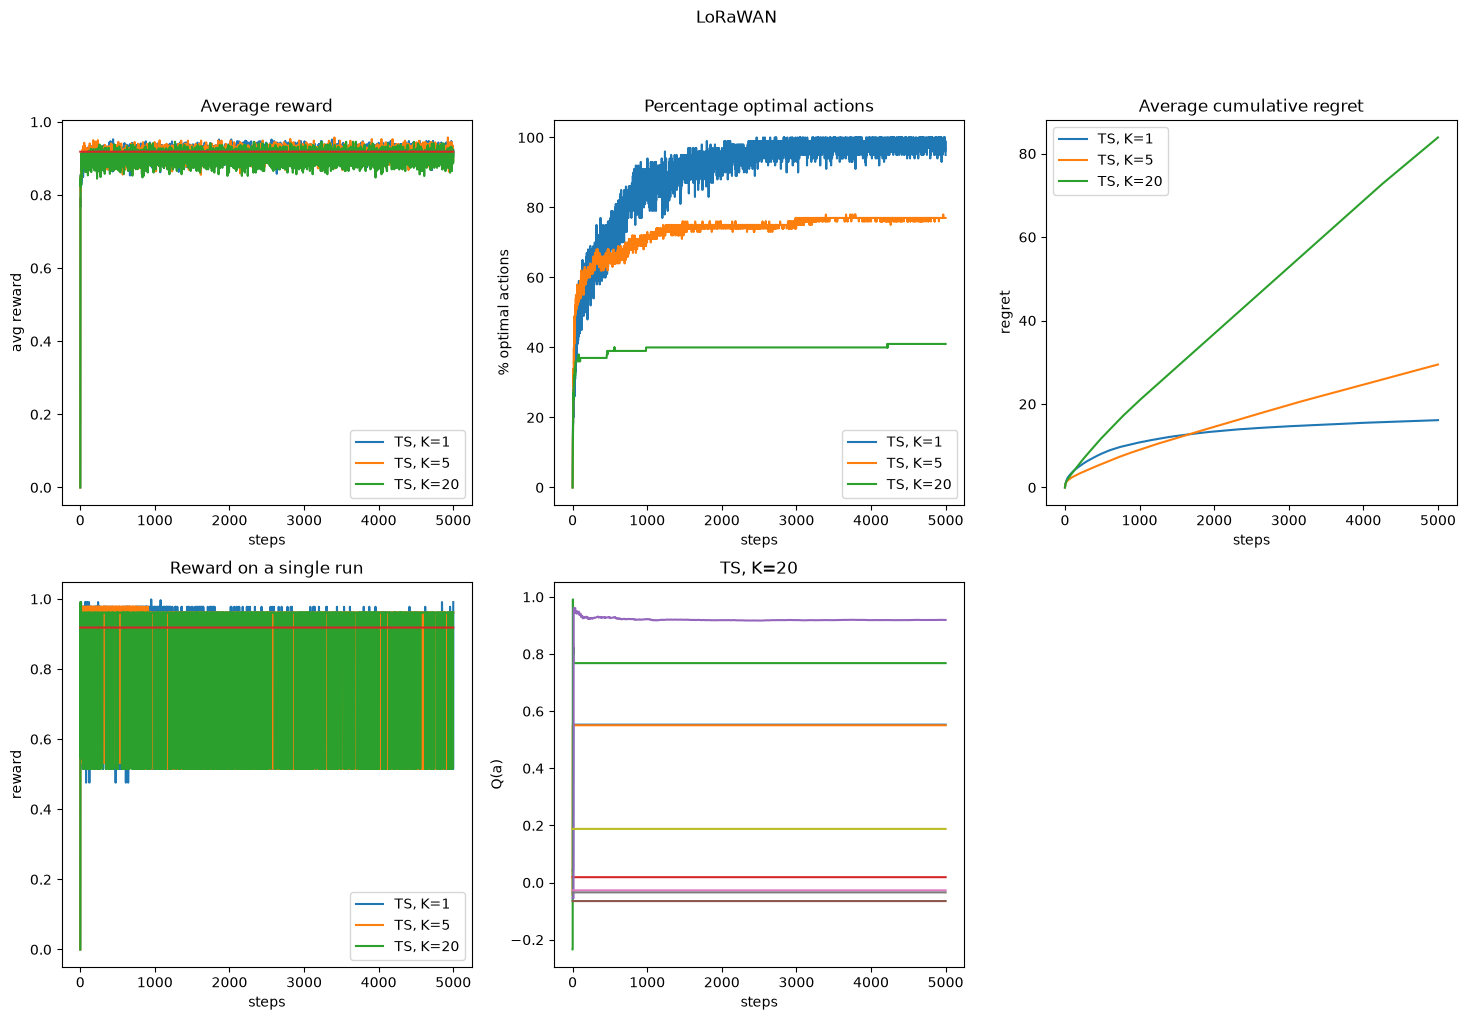

In [ ]:
avg_r, avg_ba, avg_reg, single_r, Q = resultsL[2]
generate_plot(avg_r, avg_ba, avg_reg, single_r, Q, 2, parsL[2], 'LoRaWAN', qA[bestL])

In [ ]:
avg_r, avg_ba, avg_reg, single_r, Q = resultsL[2]
for k, K in enumerate(parsL[2]):
    print('TS, K =', K)
    print('avg reward in convergence:', np.mean(avg_r[k][-100:]).round(3), 'optimum:', qA[bestL].round(3))
    print('% optimal actions at the end:', np.mean(avg_ba[k][-100:]).round())
    print('final regret:', avg_reg[k][-1].round(1))

TS, K = 1
avg reward in convergence: 0.918 optimum: 0.918
% optimal actions at the end: 98.0
final regret: 16.1
TS, K = 5
avg reward in convergence: 0.913 optimum: 0.918
% optimal actions at the end: 77.0
final regret: 29.5
TS, K = 20
avg reward in convergence: 0.902 optimum: 0.918
% optimal actions at the end: 41.0
final regret: 83.9


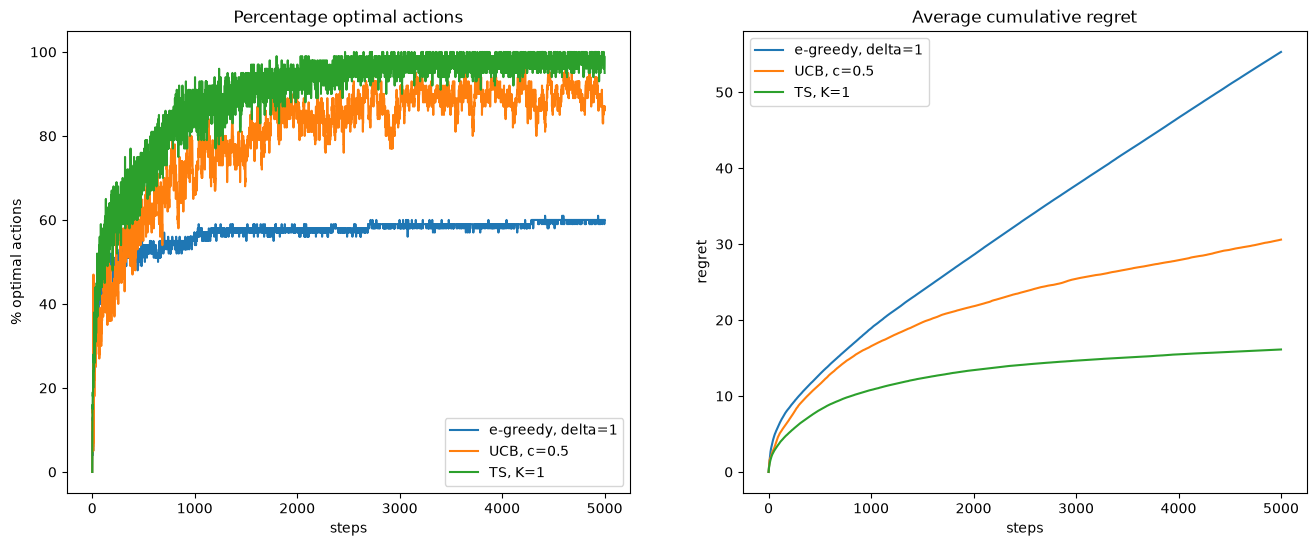

In [ ]:
# best parameter of every method: e-greedy delta=1, UCB c=0.5, TS K=1
best = [(resultsL[0], 2, 'e-greedy, delta=1'), (resultsL[1], 0, 'UCB, c=0.5'), (resultsL[2], 0, 'TS, K=1')]

fig, ax = plt.subplots(1, 2, figsize=(16, 6))
for res, k, name in best:
    ax[0].plot(res[1][k], label=name)
    ax[1].plot(res[2][k], label=name)
insert_labels({'title': 'Percentage optimal actions', 'xlabel': 'steps', 'ylabel': '% optimal actions'}, ax[0])
insert_labels({'title': 'Average cumulative regret', 'xlabel': 'steps', 'ylabel': 'regret'}, ax[1])
ax[0].legend()
ax[1].legend()
plt.show()

With $K=1$ Thompson sampling chooses the best arm $98\%$ of the time at the end, with an average reward equal to $V^*$ and a final regret of $16.1$. A larger K reduces the exploration: $K=5$ stays at $77\%$ and with $K=20$ the percentage of correct decisions stops at $41\%$ and the regret grows almost linearly ($83.9$), as it locks on suboptimal arms. As expected, averaging more samples reduces the uncertainty and therefore the exploration.

In the $Q(a)$ plot for $K=20$ only one arm keeps being updated almost from the start, and the others stay at the value of their first observations.

Comparing the best parameter of each method, Thompson sampling is the best in the whole run: its percentage of correct decisions grows faster and reaches almost $100\%$, while UCB with $c=0.5$ ends at $89\%$ and e-greedy with $\delta=1$ at $60\%$. Its final regret ($16.1$) is about half of UCB ($30.6$) and a third of e-greedy ($55.3$), and it is the flattest curve.

### f)

To make the environment non-stationary I follow the second experiment of [Kerkouche et al., 2018]: the node moves from $592$ m to $1975$ m from the gateway in the middle of the run (here at $t = 2500$ of $5000$). Only the path loss changes, $PL = 118$ dB before and $PL = 136$ dB after (same Okumura-Hata model), so $p(a)$, $Q(a)$ and the best arm $a^*$ change at that step.

In [ ]:
tSwitch = 2500                                                    # step where the node moves
PL1, PL2 = 118, 136                                               # path loss at 592 m and 1975 m (dB)
pA1, qA1 = lora_values(PL1)
pA2, qA2 = lora_values(PL2)
pA_t = np.array([pA1 if j <= tSwitch else pA2 for j in range(NStepsL)])
qA_t = np.array([qA1 if j <= tSwitch else qA2 for j in range(NStepsL)])

print('Q(a) at 592 m: ', qA1.round(3), '-> best arm', np.argmax(qA1) + 1)
print('Q(a) at 1975 m:', qA2.round(3), '-> best arm', np.argmax(qA2) + 1)

resultsNS = run_lora(pA_t, qA_t)

Q(a) at 592 m:  [0.823 0.916 0.957 0.964 0.954 0.918 0.858 0.725 0.445] -> best arm 4
Q(a) at 1975 m: [0.553 0.551 0.548 0.592 0.679 0.746 0.761 0.66  0.403] -> best arm 7


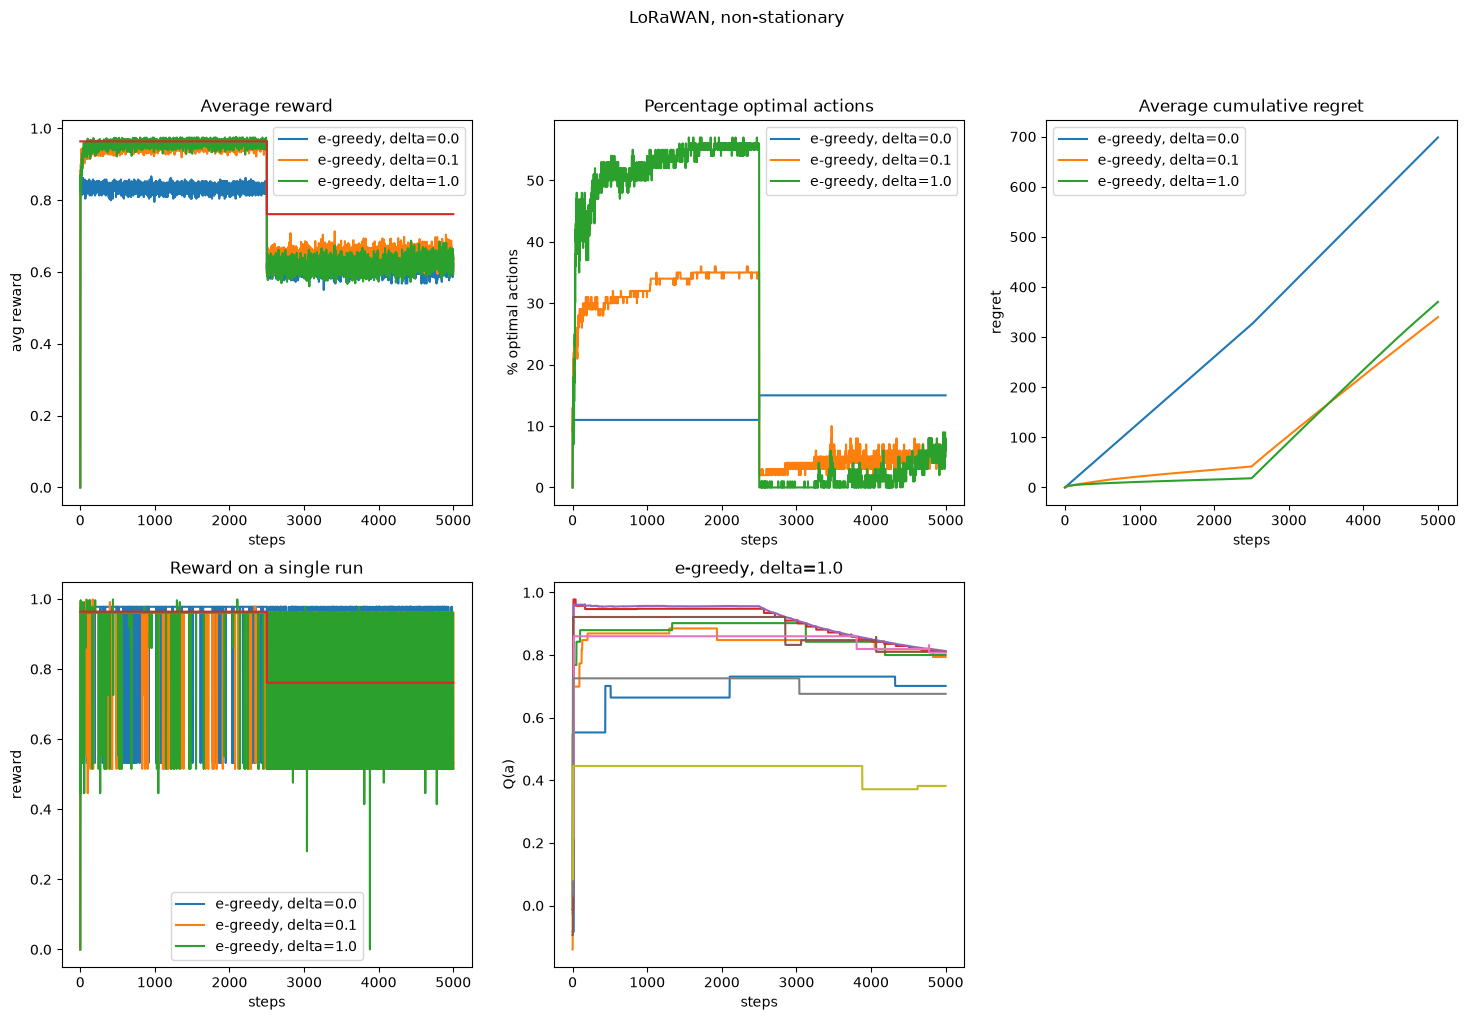

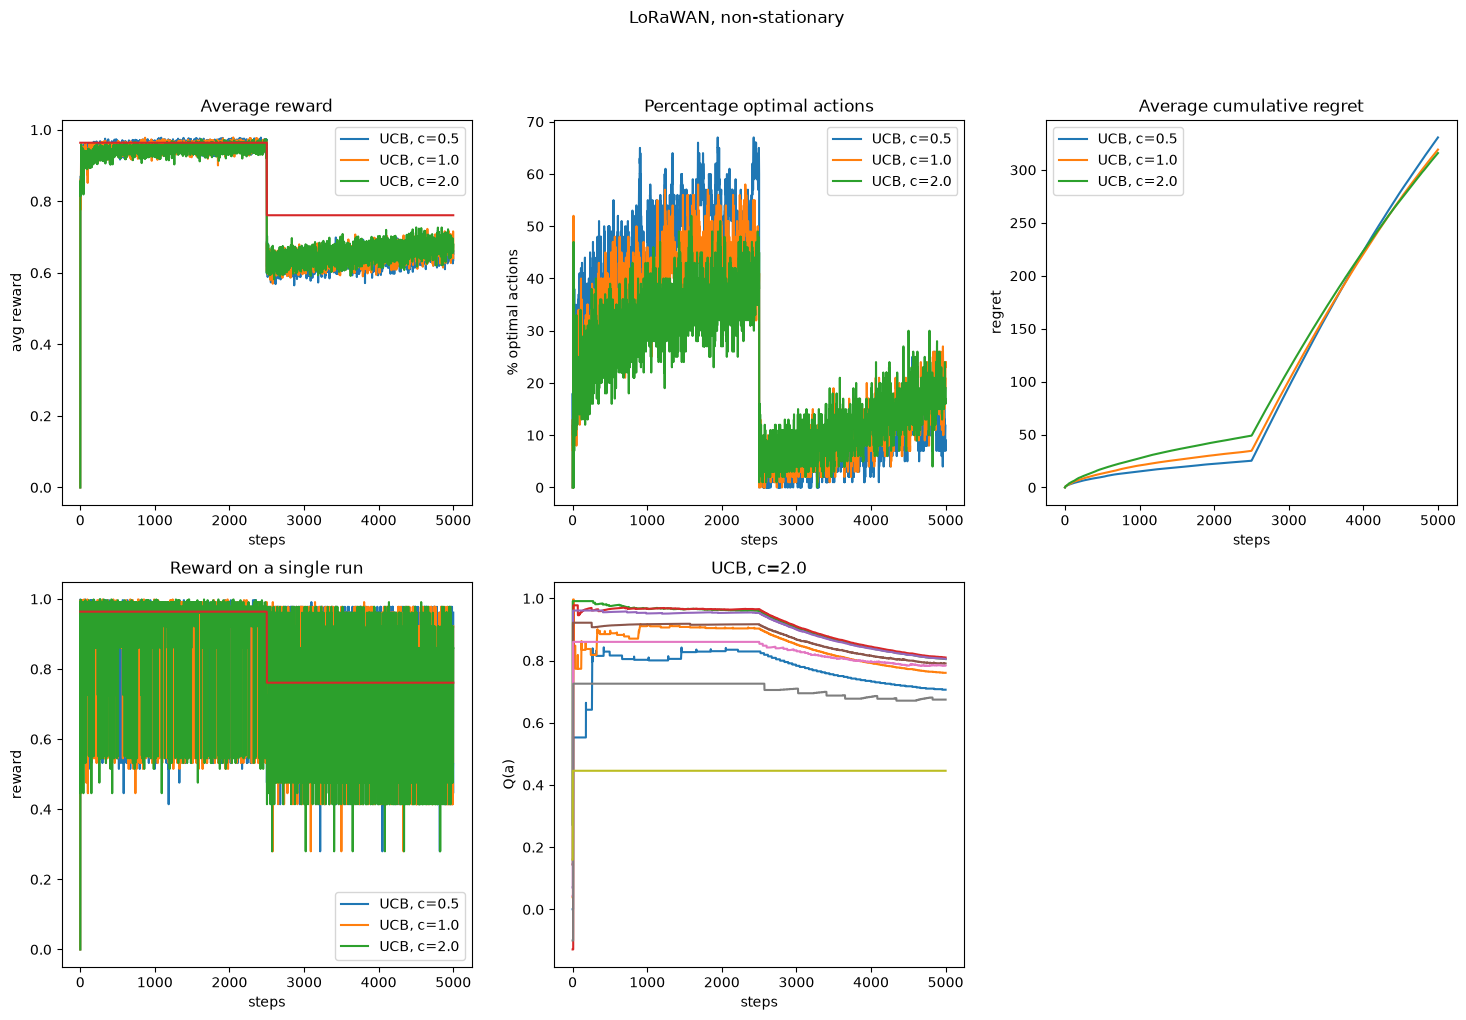

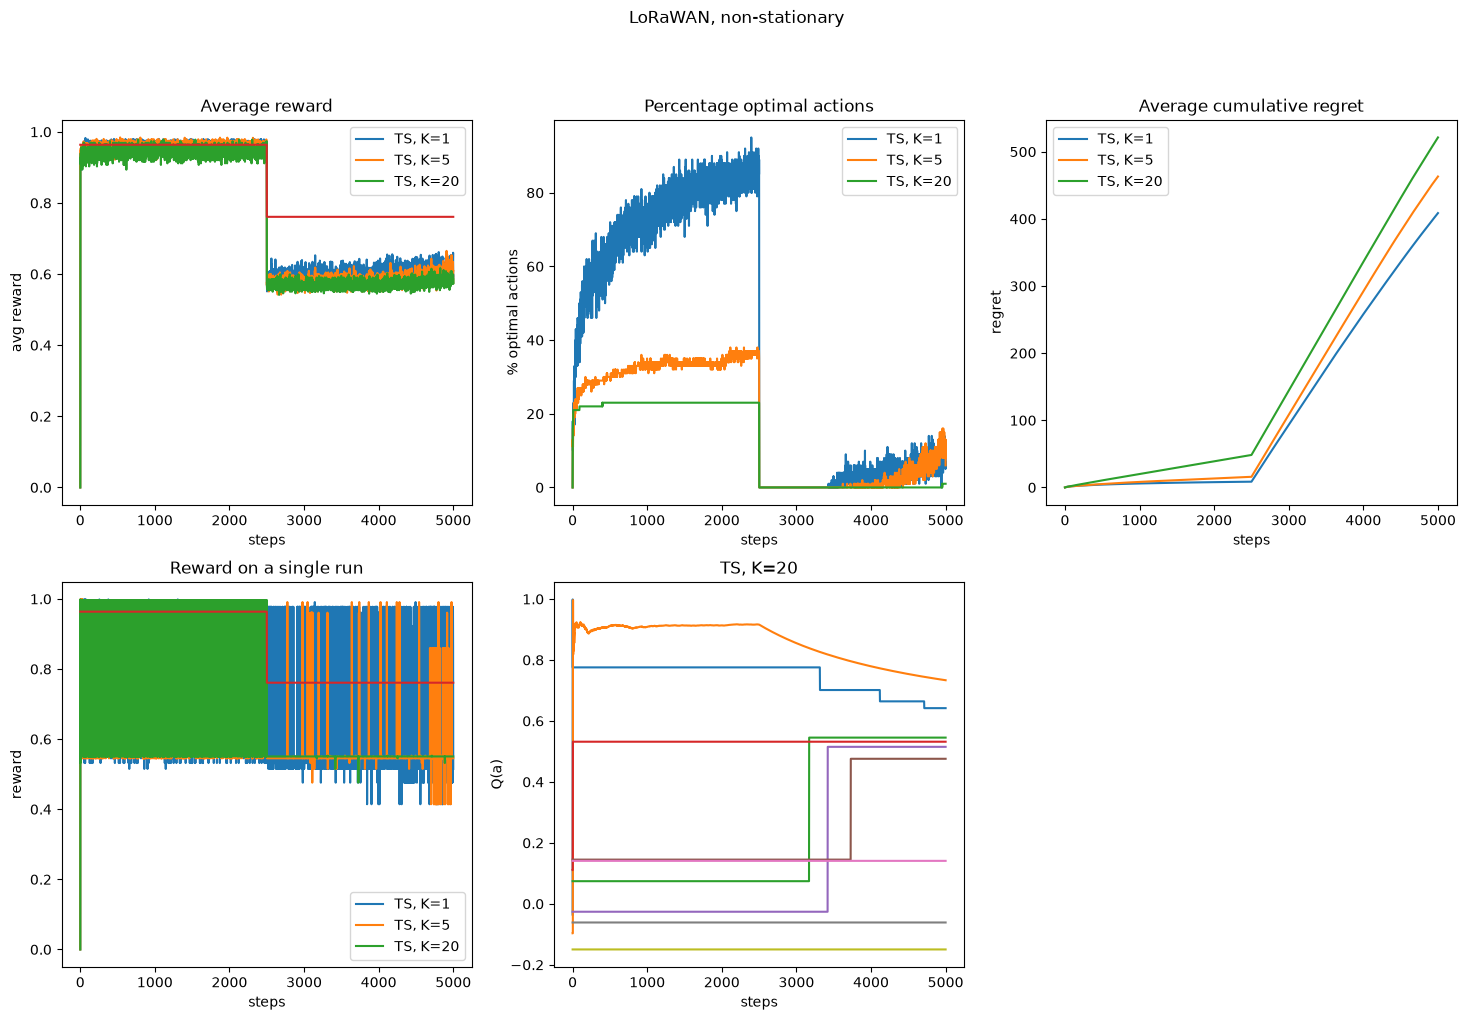

In [ ]:
for Strat in [0, 1, 2]:
    avg_r, avg_ba, avg_reg, single_r, Q = resultsNS[Strat]
    generate_plot(avg_r, avg_ba, avg_reg, single_r, Q, Strat, parsL[Strat], 'LoRaWAN, non-stationary', np.max(qA_t, axis=1))

In [ ]:
for Strat in [0, 1, 2]:
    avg_r, avg_ba, avg_reg, single_r, Q = resultsNS[Strat]
    for k, p in enumerate(parsL[Strat]):
        print(['e-greedy, delta =', 'UCB, c =', 'TS, K ='][Strat], p)
        print('% optimal actions before the switch:', np.mean(avg_ba[k][tSwitch-100:tSwitch]).round(), 'at the end:', np.mean(avg_ba[k][-100:]).round())
        print('regret at the switch:', avg_reg[k][tSwitch].round(1), 'at the end:', avg_reg[k][-1].round(1))

e-greedy, delta = 0.0
% optimal actions before the switch: 11.0 at the end: 15.0
regret at the switch: 324.9 at the end: 698.2
e-greedy, delta = 0.1
% optimal actions before the switch: 35.0 at the end: 5.0
regret at the switch: 41.7 at the end: 339.7
e-greedy, delta = 1.0
% optimal actions before the switch: 56.0 at the end: 5.0
regret at the switch: 18.0 at the end: 370.2
UCB, c = 0.5
% optimal actions before the switch: 61.0 at the end: 11.0
regret at the switch: 25.2 at the end: 330.7
UCB, c = 1.0
% optimal actions before the switch: 45.0 at the end: 19.0
regret at the switch: 34.6 at the end: 319.2
UCB, c = 2.0
% optimal actions before the switch: 40.0 at the end: 19.0
regret at the switch: 48.8 at the end: 315.9
TS, K = 1
% optimal actions before the switch: 86.0 at the end: 8.0
regret at the switch: 8.6 at the end: 408.6
TS, K = 5
% optimal actions before the switch: 37.0 at the end: 11.0
regret at the switch: 15.8 at the end: 463.1
TS, K = 20
% optimal actions before the switch

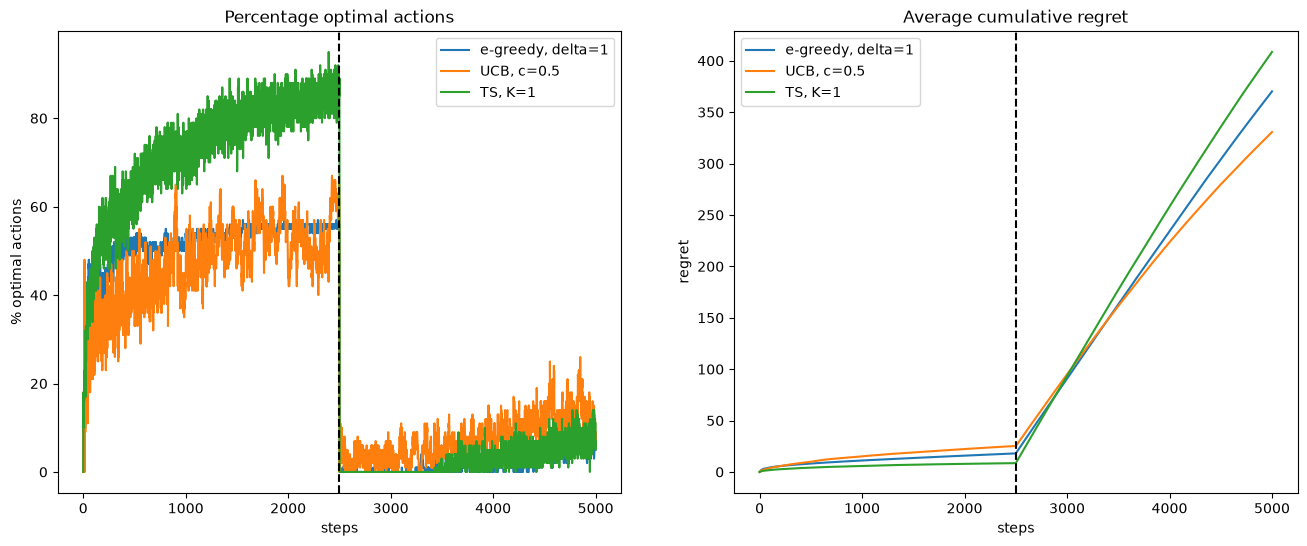

In [ ]:
# best parameter of every method in d) and e): e-greedy delta=1, UCB c=0.5, TS K=1
best = [(resultsNS[0], 2, 'e-greedy, delta=1'), (resultsNS[1], 0, 'UCB, c=0.5'), (resultsNS[2], 0, 'TS, K=1')]

fig, ax = plt.subplots(1, 2, figsize=(16, 6))
for res, k, name in best:
    ax[0].plot(res[1][k], label=name)
    ax[1].plot(res[2][k], label=name)
for i in range(2):
    ax[i].axvline(tSwitch, color='k', linestyle='--')            
    ax[i].legend()
insert_labels({'title': 'Percentage optimal actions', 'xlabel': 'steps', 'ylabel': '% optimal actions'}, ax[0])
insert_labels({'title': 'Average cumulative regret', 'xlabel': 'steps', 'ylabel': 'regret'}, ax[1])
plt.show()

At $1975$ m, the optimal arm is arm 7 (SF10, 14 dBm, $Q(a^*) = 0.761$), so the arm learned in the first half is no longer the best one after the switch.

Before the switch the methods behave as in d) and e). After the switch all the methods fail: the percentage of correct decisions drops to $0$-$20\%$ for every parameter and the regret grows almost linearly until the end. The average reward stays below the new optimum and the estimated $Q(a)$ in the single run plots decreases very slowly towards the new values.

In all three methods the estimates use all the past observations with the same weight and the exploration decreases with time. After the switch the old observations dominate the estimates, so they cannot follow the change.

### g)

I chose UCB. Following the slides, for a non-stationary environment the estimate is updated with a constant step size $\alpha$, which gives more weight to the recent rewards:

$$\hat{Q}_{t+1}(a) = \hat{Q}_t(a) + \alpha \left( r_t - \hat{Q}_t(a) \right)$$

With a constant $\alpha$ the estimate depends on its initial value, and starting from $\hat{Q}_0(a) \approx 0$ it needs many pulls to reach the true value. To avoid it, the step is $\max(1/N_t(a), \alpha)$: the first $1/\alpha$ pulls of each arm are a normal average and then the step stays at $\alpha$.

It is implemented as a fourth strategy in the simulation function of d).

In [ ]:
resultsG = run_lora(pA_t, qA_t, [3])[0]

avg_r, avg_ba, avg_reg, single_r, Q = resultsG
generate_plot(avg_r, avg_ba, avg_reg, single_r, Q, 3, parsL[3], 'LoRaWAN, non-stationary', np.max(qA_t, axis=1))

TypeError: run_lora() takes 2 positional arguments but 3 were given

In [ ]:
print('UCB, c = 0.5 (section f)')
print('% optimal actions before the switch:', np.mean(resultsNS[1][1][0][tSwitch-100:tSwitch]).round(), 'at the end:', np.mean(resultsNS[1][1][0][-100:]).round())
print('regret at the switch:', resultsNS[1][2][0][tSwitch].round(1), 'at the end:', resultsNS[1][2][0][-1].round(1))
for k, a in enumerate(parsL[3]):
    print('UCB tracking, alpha =', a)
    print('% optimal actions before the switch:', np.mean(avg_ba[k][tSwitch-100:tSwitch]).round(), 'at the end:', np.mean(avg_ba[k][-100:]).round())
    print('regret at the switch:', avg_reg[k][tSwitch].round(1), 'at the end:', avg_reg[k][-1].round(1))

In [ ]:
# UCB with c=0.5 from f) vs UCB tracking
fig, ax = plt.subplots(1, 2, figsize=(16, 6))
ax[0].plot(resultsNS[1][1][0], label='UCB, c=0.5')
ax[1].plot(resultsNS[1][2][0], label='UCB, c=0.5')
for k, a in enumerate(parsL[3]):
    ax[0].plot(avg_ba[k], label='UCB tracking, alpha={}'.format(a))
    ax[1].plot(avg_reg[k], label='UCB tracking, alpha={}'.format(a))
for i in range(2):
    ax[i].axvline(tSwitch, color='k', linestyle='--')                 # step where the node moves
    ax[i].legend()
insert_labels({'title': 'Percentage optimal actions', 'xlabel': 'steps', 'ylabel': '% optimal actions'}, ax[0])
insert_labels({'title': 'Average cumulative regret', 'xlabel': 'steps', 'ylabel': 'regret'}, ax[1])
plt.show()

After the switch UCB tracking finds the new best arm: the percentage of correct decisions goes up to $66\%$, $74\%$ and $78\%$ for $\alpha = 0.01, 0.02, 0.05$, while the original UCB stays at $11\%$. The regret stops growing linearly and ends at $89$-$113$, about a third of the $330.7$ of the original UCB. In the single run plot the estimated $Q(a)$ drop to the new values in a few hundred steps after the switch, and the average reward gets close to the new optimum.

A larger $\alpha$ forgets the old rewards faster, so it reacts sooner after the switch and ends with the lowest regret ($89.0$ for $\alpha = 0.05$).

The cost is a worse performance while the environment does not change: before the switch UCB tracking chooses the best arm $35$-$40\%$ of the time vs $61\%$ for the original UCB, and its regret at the switch is a bit higher ($28.7$-$39.3$ vs $25.2$), growing with $\alpha$. As the slides say, with a constant step the estimates never converge and keep varying with the recent rewards, which can be seen in the noisy $Q(a)$ of the chosen arm. The value of $\alpha$ is a trade-off between precision in a stationary period and speed of adaptation after a change.